# Complete ThermoML snapshot exploratory analysis

**Question.** What publications, property types, properties, system orders,
chemical systems, components, methods, and dense datasets occur in the full
versioned NIST/TRC ThermoML snapshot?

**Success criteria.** Verify the official snapshot checksum; scan every XML
member; report the top 10 for every requested ranking; distinguish datasets,
data points, and property observations; and explicitly list any member that
cannot be decoded.

This notebook analyzes the NIST snapshot published under DOI
`10.18434/mds2-2422`. The snapshot covers archive entries through the 2019
publication year. It is a reproducible census of that version, not a claim
about records added to the live service later.

In [1]:
from __future__ import annotations

import platform
from dataclasses import asdict
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from thermoml_io import (
    analyze_thermoml_archive,
    fetch_thermoml_archive,
    get_archive_source,
)

pd.set_option("display.max_colwidth", 120)


def find_project_root(start: Path) -> Path:
    """Locate the repository root independently of the kernel directory."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("Could not locate the thermoml-io project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
print(
    {
        "python": platform.python_version(),
        "thermoml-io": version("thermoml-io"),
        "pandas": version("pandas"),
        "platform": platform.platform(),
    }
)

{'python': '3.14.6', 'thermoml-io': '0.1.0', 'pandas': '3.0.5', 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O'}


## Source, checksum, and local-only boundary

Automated archive studies should use the bulk snapshot instead of issuing
thousands of requests to the live search service. The 189 MB compressed file
is cached under the ignored `notebooks/local-only/` directory and is never
included in the Python distributions.

In [2]:
archive_source = get_archive_source()
ARCHIVE_PATH = fetch_thermoml_archive(cache_dir=PROJECT_ROOT / "notebooks/local-only/archive")
display(
    pd.DataFrame(
        [
            {
                "dataset DOI": archive_source.doi.removeprefix("doi:"),
                "snapshot": ARCHIVE_PATH.name,
                "cutoff": "entries published through 2019",
                "compressed bytes": ARCHIVE_PATH.stat().st_size,
                "SHA-256": archive_source.sha256,
                "local path": str(ARCHIVE_PATH.relative_to(PROJECT_ROOT)),
            }
        ]
    )
)

,dataset DOI,snapshot,cutoff,compressed bytes,SHA-256,local path
0,10.18434/mds2-2422,ThermoML.v2020-09-30.tgz,entries published through 2019,189433115,231161b5e443dc1ae0e5da8429d86a88474cb722016e5b790817bb31c58d7ec2,notebooks/local-only/archive/ThermoML.v2020-09-30.tgz


## Complete streaming scan

`on_error="collect"` retains unrecovered failures explicitly. XML is always
attempted first; the paired official NIST JSON is used only after an XML
parsing failure, and every such event is listed in `analysis.recoveries`.

In [3]:
started = perf_counter()
analysis = analyze_thermoml_archive(
    ARCHIVE_PATH,
    top_datasets=10,
    on_error="collect",
)
elapsed_seconds = perf_counter() - started
summary = analysis.summary

overview = pd.DataFrame(
    {
        "metric": [
            "XML members in snapshot",
            "documents decoded",
            "pure/mixture datasets decoded",
            "NumValues data points",
            "property observations",
            "reaction datasets detected",
            "official JSON recoveries",
            "unrecovered decoding failures",
            "elapsed seconds",
        ],
        "count": [
            analysis.xml_document_count,
            analysis.parsed_document_count,
            summary.dataset_count,
            summary.data_point_count,
            summary.observation_count,
            summary.reaction_dataset_count,
            len(analysis.recoveries),
            len(analysis.failures),
            round(elapsed_seconds, 2),
        ],
    }
)
display(overview)

,metric,count
0,XML members in snapshot,11923.00
1,documents decoded,11923.00
2,pure/mixture datasets decoded,122481.00
3,NumValues data points,2690357.00
4,property observations,2784119.00
5,reaction datasets detected,1246.00
6,official JSON recoveries,2.00
7,unrecovered decoding failures,0.00
8,elapsed seconds,128.54


## Top-10 rankings

Except for “system orders by dataset”, counts are weighted by individual
property observations. This makes the ranking consistent with the search API
and prevents a publication containing many tiny datasets from appearing
denser than one containing more measured values.

In [4]:
RANKINGS = (
    ("data_types", "Derived data categories"),
    ("property_groups", "Original ThermoML property groups"),
    ("properties", "Reported properties"),
    ("dataset_system_types", "System orders — datasets"),
    ("system_types", "System orders — observations"),
    ("systems", "Chemical systems"),
    ("components", "Components"),
    ("methods", "Experimental methods"),
    ("publications", "Publications"),
)

ranking_frames: dict[str, pd.DataFrame] = {}
for field, title in RANKINGS:
    frame = pd.DataFrame(
        [
            {"rank": rank, "label": item.label, "count": item.count}
            for rank, item in enumerate(summary.top(field, 10), start=1)
        ]
    )
    ranking_frames[field] = frame
    print(f"\n{title} — top 10")
    display(frame)


Derived data categories — top 10


,rank,label,count
0,1,volumetric,879217
1,2,transport,393768
2,3,"interfacial, optical, and acoustic",356360
3,4,vapor pressure and boiling,232413
4,5,caloric,221630
5,6,VLE,164136
6,7,LLE,155238
7,8,SLE,150524
8,9,excess and partial energy,80296
9,10,"activity, fugacity, and osmotic",69285



Original ThermoML property groups — top 10


,rank,label,count
0,1,VolumetricProp,879217
1,2,CompositionAtPhaseEquilibrium,490780
2,3,TransportProp,393768
3,4,RefractionSurfaceTensionSoundSpeed,356360
4,5,VaporPBoilingTAzeotropTandP,232413
5,6,HeatCapacityAndDerivedProp,221630
6,7,ExcessPartialApparentEnergyProp,80296
7,8,ActivityFugacityOsmoticProp,69285
8,9,PhaseTransition,55698
9,10,Criticals,4672



Reported properties — top 10


...

,rank,label,count
0,1,water,927862
1,2,ethanol,168259
2,3,carbon dioxide,129176
3,4,methanol,114742
4,5,propan-1-ol,77210
5,6,propan-2-ol,70624
6,7,butan-1-ol,65904
7,8,heptane,61767
8,9,toluene,53736
9,10,hexane,43790



Experimental methods — top 10


,rank,label,count
0,1,Vibrating tube method,551061
1,2,Chromatography,252659
2,3,Capillary tube (Ostwald; Ubbelohde) method,106372
3,4,Standard Abbe refractometry,79517
4,5,Sing-around technique in a fixed-path interferometer,77960
5,6,Closed cell (Static) method,73521
6,7,Titration method,59138
7,8,Ebulliometric method (Recirculating still),57768
8,9,Small sample (50 mg) DSC,53927
9,10,VIBTUB:UFactor:4,52605



Publications — top 10


,rank,label,count
0,1,10.1021/je060271a,32441
1,2,10.1016/j.jct.2018.01.019,17801
2,3,10.1021/je800110r,8917
3,4,10.1021/je900927a,7901
4,5,10.1021/je700260f,6615
5,6,10.1021/acs.jced.8b00157,6099
6,7,10.1021/acs.jced.5b00845,5688
7,8,10.1016/j.jct.2015.10.004,4947
8,9,10.1021/je800150h,4802
9,10,10.1021/je900596d,4301


## Ten densest datasets

Dataset ranking uses all property observations in each supported
`PureOrMixtureData` entry and is truncated only after the entire snapshot has
been processed.

In [5]:
dense_records = []
for rank, item in enumerate(analysis.top_datasets, start=1):
    record = asdict(item)
    locator = record.pop("source_locator")
    record["archive_member"] = locator.rsplit("!", maxsplit=1)[-1] if locator else None
    dense_records.append({"rank": rank, **record})
dense_datasets = pd.DataFrame(dense_records)
display(dense_datasets)

,rank,doi,citation_title,dataset_number,system,system_type,observation_count,data_types,archive_member
0,1,10.1021/je060271a,PGT Experimental Measurements and Data Correlation of Pentaerythritol Esters,3,pentaerythritol tetrahexanoate,pure,10245,"(volumetric,)",10.1021/je060271a.xml
1,2,10.1021/je800110r,Temperature and Pressure Dependence of Branched Pentaerythritol Ester Density,4,decane,pure,8773,"(volumetric,)",10.1021/je800110r.xml
2,3,10.1021/je060271a,PGT Experimental Measurements and Data Correlation of Pentaerythritol Esters,4,pentaerythritol tetraheptanoate,pure,7530,"(volumetric,)",10.1021/je060271a.xml
3,4,10.1021/je700260f,"Compressed Liquid Density Measurements for 1,1,1,2,3,3,3-Heptafluoropropane (R227ea)",1,"1,1,1,2,3,3,3-heptafluoropropane",pure,6615,"(volumetric,)",10.1021/je700260f.xml
4,5,10.1021/je060271a,PGT Experimental Measurements and Data Correlation of Pentaerythritol Esters,2,pentaerythritol tetrapentanoate,pure,5151,"(volumetric,)",10.1021/je060271a.xml
5,6,10.1021/je060271a,PGT Experimental Measurements and Data Correlation of Pentaerythritol Esters,1,pentaerythritol tetrabutyrate,pure,4770,"(volumetric,)",10.1021/je060271a.xml
6,7,10.1021/je060271a,PGT Experimental Measurements and Data Correlation of Pentaerythritol Esters,5,pentaerythritol tetraoctanoate,pure,4745,"(volumetric,)",10.1021/je060271a.xml
7,8,10.1021/acs.jced.8b00157,Temperatures of Primary Crystallization and Density of the KF + AlF3 + LiF + Al2O3 Molten System,4,aluminum fluoride + lithium fluoride + potassium fluoride,ternary,3825,"(volumetric,)",10.1021/acs.jced.8b00157.xml
8,9,10.1016/j.jct.2016.03.026,Thermodynamic properties of a CO2-rich mixture (CO2 + CH3OH) in conditions of interest for carbon dioxide capture an...,2,carbon dioxide + methanol,binary,3341,"(volumetric,)",10.1016/j.jct.2016.03.026.xml
9,10,10.1016/j.jct.2018.01.019,"P21/c-C2/c phase transition and mixing properties of the (Li,Na)FeGe2O6 solid solution: A calorimetric and thermodyn...",20,germanium iron lithium oxide (Ge2FeLiO6) + germanium iron sodium oxide (Ge2FeNaO6),binary,3207,"(caloric,)",10.1016/j.jct.2018.01.019.xml


## Visual comparison

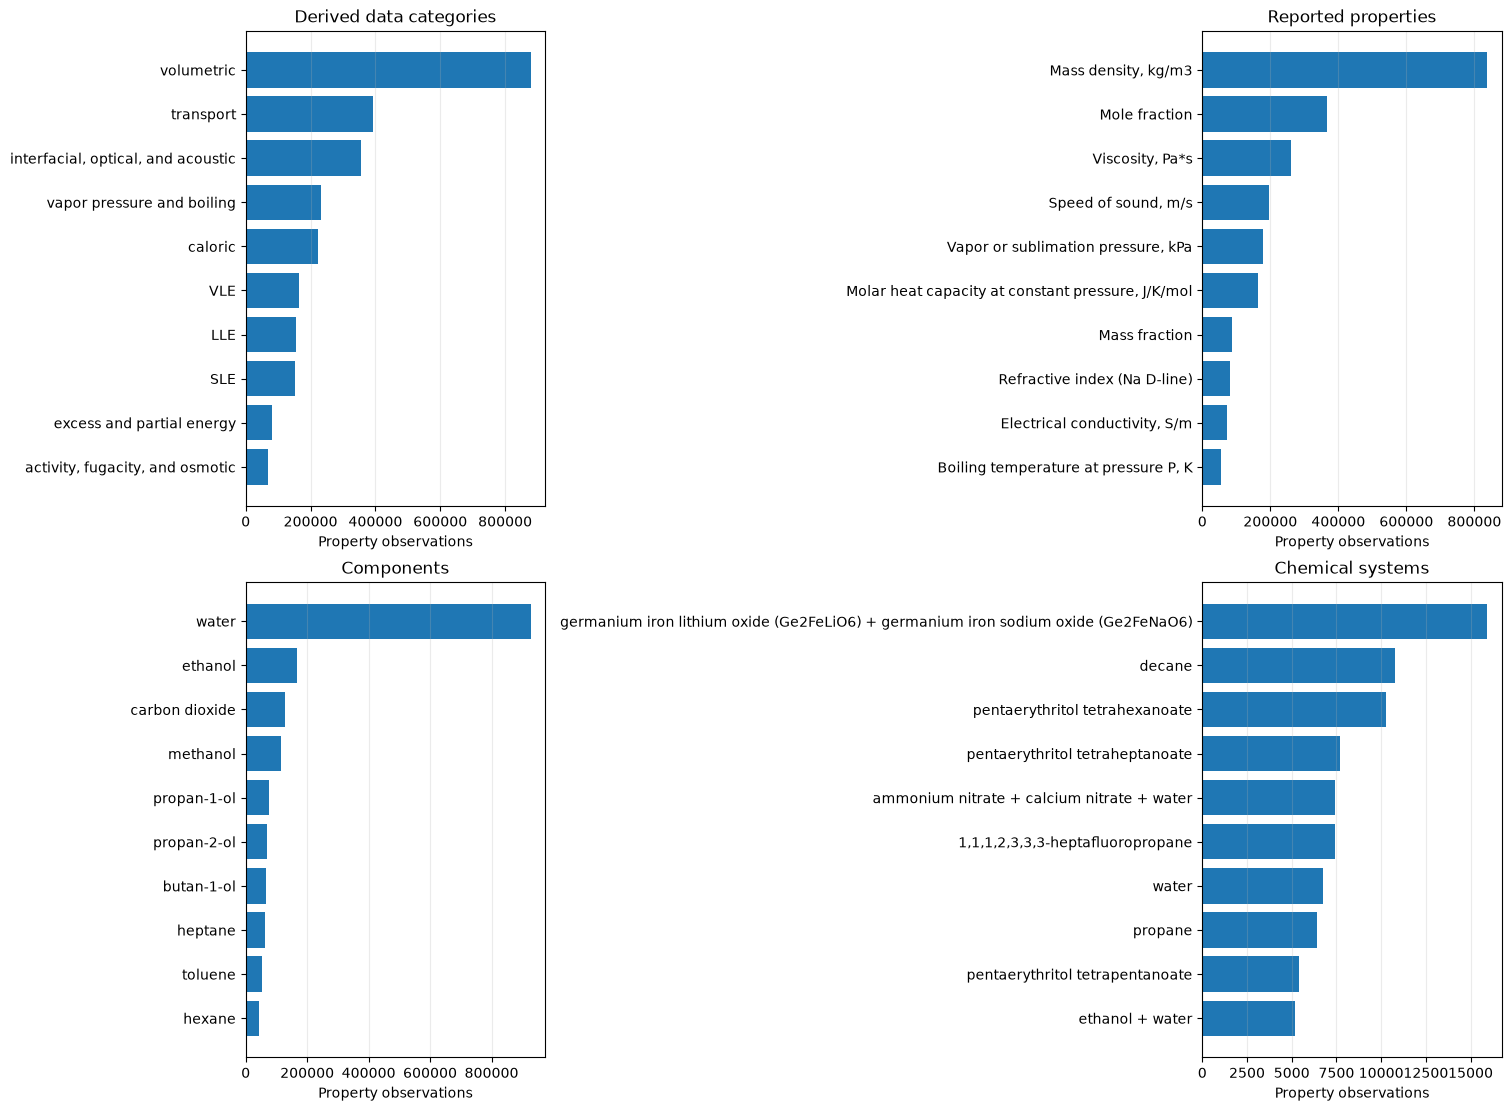

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
for axis, field, title in (
    (axes[0, 0], "data_types", "Derived data categories"),
    (axes[0, 1], "properties", "Reported properties"),
    (axes[1, 0], "components", "Components"),
    (axes[1, 1], "systems", "Chemical systems"),
):
    frame = ranking_frames[field].sort_values("count")
    axis.barh(frame["label"], frame["count"])
    axis.set_title(title)
    axis.set_xlabel("Property observations")
    axis.grid(axis="x", alpha=0.25)
plt.show()

## Explicit source recoveries and failures

Recovery never edits the XML. It preserves the rejected XML locator, hash,
and exception, then parses the same-path official JSON as a distinct source.

In [7]:
recovery_frame = pd.DataFrame(
    [
        {
            "XML member": item.xml_member_name,
            "JSON member": item.json_member_name,
            "XML SHA-256": item.xml_sha256,
            "JSON SHA-256": item.json_sha256,
            "XML error": item.error_message,
            "XML lexical decimals preserved": (item.lexical_numeric_representation_preserved),
        }
        for item in analysis.recoveries
    ]
)
display(recovery_frame)

,XML member,JSON member,XML SHA-256,JSON SHA-256,XML error,XML lexical decimals preserved
0,10.1016/j.fluid.2018.07.020.xml,10.1016/j.fluid.2018.07.020.json,9f4823c13452cef5f174038a666685ee1802757cca698870e01eb23dfb2d66e9,c716ccb6f6f7438e09d4f80e2b5bea3422622411cdcf56665106804b649e90ca,"Invalid or unsafe ThermoML XML: not well-formed (invalid token): line 231, column 19",False
1,10.1016/j.fluid.2018.07.021.xml,10.1016/j.fluid.2018.07.021.json,ca216a6c63bcc0da79208d44864d76d7966ddd69947ba39e9baba4606ffee8c4,bdadc491495128061ec9ac4224ec1abdb997e9025110eed2c762224bbe55e58e,"Invalid or unsafe ThermoML XML: not well-formed (invalid token): line 205, column 19",False


In [8]:
failure_frame = pd.DataFrame(
    [
        {
            "archive_member": item.member_name,
            "error_type": item.error_type,
            "message": item.message,
        }
        for item in analysis.failures
    ]
)
if failure_frame.empty:
    print("All members were decoded directly or by explicit paired-JSON recovery.")
else:
    display(failure_frame)

All members were decoded directly or by explicit paired-JSON recovery.


## Interpretation and limitations

- The snapshot is complete only through its stated 2019 publication cutoff.
- Rankings describe archive coverage, not data quality or independent
  experimental information content.
- Friendly categories such as VLE/LLE/SLE are conservative derived views;
  the original ThermoML property-group ranking is shown separately.
- `ReactionData` entries are counted but are not yet decoded into the v0.1
  typed reaction model, so reaction observations do not enter the rankings.
- NIST/TRC representation checks are not a critical evaluation of the
  underlying experiments. Applied use requires consultation of the original
  publications and domain-specific consistency checks.